<a href="https://colab.research.google.com/github/lucasponte2006-wq/An-lises-Estat-sticas---Ci-ncia-de-dados-e-IA/blob/main/An%C3%A1lise_de_dados_financeiros_Empresa_fantasia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Análise de Faturamento, Despesas e Lucro**

**Empresa fictícia** - Setores: Tecnologia, Comercial e Operações (2022-2023)

Este notebook realiza uma análise exploratória dos dados financeiros de uma empresa, avaliando:
  
  **-Faturamento**
  
  **-Evolução das despesas**
  
  **-Cálculo e análise do lucro líquido**
  
  **-Comparativo entre anos e setores**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#Configurações visuais
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

#Carregar dados
df = pd.read_csv('dados_financeiros.csv')

#Calcular colunas derivadas
df['despesas_totais'] = df['despesas_fixas'] + df['despesas_variaveis'] + df['impostos']
df['lucro_liquido']   = df['faturamento'] - df['despesas_totais']
df['margem_lucro']    = (df['lucro_liquido'] / df['faturamento'] * 100).round(2)

#Ordem dos meses
ordem_meses = ['Janeiro','Fevereiro','Março','Abril','Maio','Junho',
               'Julho','Agosto','Setembro','Outubro','Novembro','Dezembro']
df['mes'] = pd.Categorical(df['mes'], categories=ordem_meses, ordered=True)

df.head()



,mes,ano,setor,faturamento,despesas_fixas,despesas_variaveis,impostos,despesas_totais,lucro_liquido,margem_lucro
0,Janeiro,2022,Tecnologia,125000,32000,18500,12500,63000,62000,49.60
1,Fevereiro,2022,Tecnologia,118000,32000,17200,11800,61000,57000,48.31
2,Março,2022,Tecnologia,134000,32000,19800,13400,65200,68800,51.34
3,Abril,2022,Tecnologia,142000,32000,21000,14200,67200,74800,52.68
4,Maio,2022,Tecnologia,138000,32000,20300,13800,66100,71900,52.10


#1. Visão Geral dos Dados

In [9]:
print('Shape', df.shape)
print('\nEstatísticas descritivas:')
df[['faturamento','despesas_totais','lucro_liquido','margem_lucro']].describe().round(2)

Shape (72, 10)

Estatísticas descritivas:


,faturamento,despesas_totais,lucro_liquido,margem_lucro
count,72.00,72.00,72.00,72.00
mean,132722.22,59872.22,72850.00,54.16
std,36906.13,13435.13,24162.49,3.70
min,70000.00,37500.00,32500.00,46.43
25%,104000.00,49375.00,54900.00,51.79
50%,129500.00,58150.00,68400.00,54.32
75%,157250.00,69400.00,86400.00,56.52
max,241000.00,94500.00,146500.00,61.41


# 2. Faturamento Total por Ano e Setor

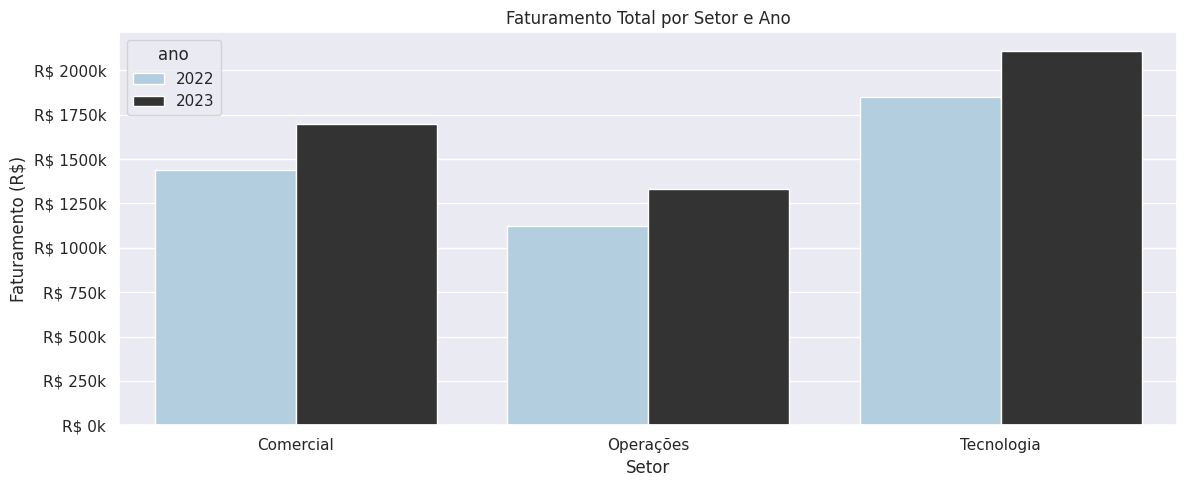

In [10]:
fat_setor_ano = df.groupby(['ano','setor'])['faturamento'].sum().reset_index()

fig, ax = plt.subplots()
sns.barplot(data=fat_setor_ano, x='setor', y='faturamento', hue='ano', palette='Blues_d', ax=ax)
ax.set_title('Faturamento Total por Setor e Ano')
ax.set_xlabel('Setor')
ax.set_ylabel('Faturamento (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))
plt.tight_layout()
plt.show()

#3. Evolução Mensal do Faturamento (todos os setores)

/tmp/ipykernel_1228/3058861871.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fat_mensal = df.groupby(['ano','mes'])['faturamento'].sum().reset_index()


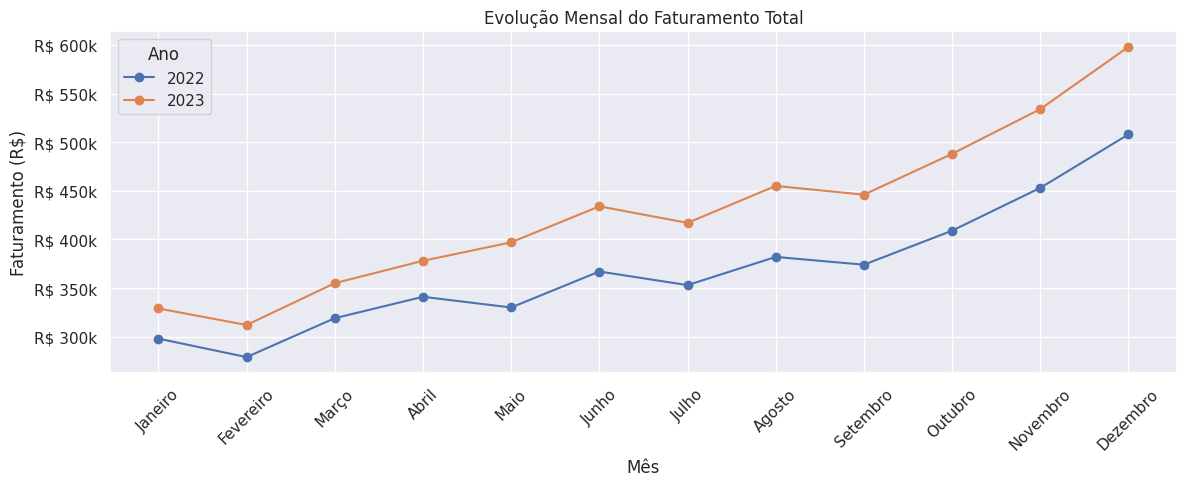

In [13]:
fat_mensal = df.groupby(['ano','mes'])['faturamento'].sum().reset_index()
fat_mensal['mes'] = pd.Categorical(fat_mensal['mes'], categories=ordem_meses, ordered=True)
fat_mensal = fat_mensal.sort_values(['ano','mes'])


fig, ax = plt.subplots()
for ano, grupo in fat_mensal.groupby('ano'):
  ax.plot(grupo['mes'].astype(str), grupo['faturamento'], marker='o', label=str(ano))

ax.set_title('Evolução Mensal do Faturamento Total')
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))
plt.xticks(rotation=45)
ax.legend(title='Ano')
plt.tight_layout()
plt.show()

#4. Faturamento vs Despesas vs Lucro por Ano

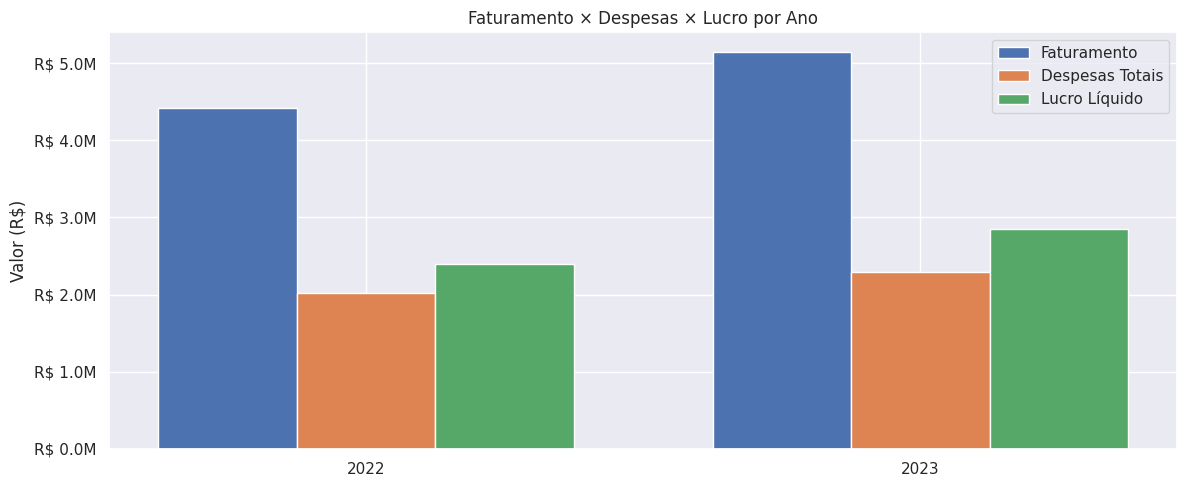

 ano  faturamento  despesas_totais  lucro_liquido
2022      4413000          2022700        2390300
2023      5143000          2288100        2854900


In [14]:
resumo_ano = df.groupby('ano')[['faturamento','despesas_totais','lucro_liquido']].sum().reset_index()

x = range(len(resumo_ano))
width = 0.25
fig, ax = plt.subplots()
ax.bar([i - width for i in x], resumo_ano['faturamento'],   width, label='Faturamento',    color='#4C72B0')
ax.bar([i          for i in x], resumo_ano['despesas_totais'], width, label='Despesas Totais', color='#DD8452')
ax.bar([i + width for i in x], resumo_ano['lucro_liquido'], width, label='Lucro Líquido',  color='#55A868')

ax.set_title('Faturamento × Despesas × Lucro por Ano')
ax.set_xticks(list(x))
ax.set_xticklabels(resumo_ano['ano'])
ax.set_ylabel('Valor (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()

print(resumo_ano.to_string(index=False))

#5. Margem de Lucro por Setor

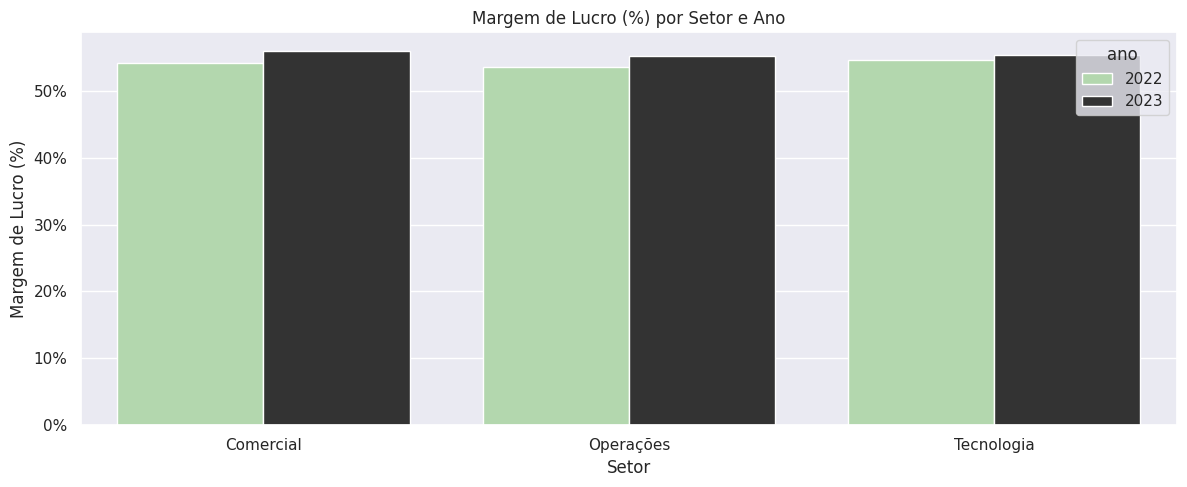

     setor  ano  faturamento  lucro_liquido  margem
 Comercial 2022      1440000         779700   54.15
 Comercial 2023      1700000         950800   55.93
 Operações 2022      1122000         601100   53.57
 Operações 2023      1334000         736200   55.19
Tecnologia 2022      1851000        1009500   54.54
Tecnologia 2023      2109000        1167900   55.38


In [15]:
margem_setor = df.groupby(['setor','ano'])[['faturamento','lucro_liquido']].sum().reset_index()
margem_setor['margem'] = (margem_setor['lucro_liquido'] / margem_setor['faturamento'] * 100).round(2)

fig, ax = plt.subplots()
sns.barplot(data=margem_setor, x='setor', y='margem', hue='ano', palette='Greens_d', ax=ax)
ax.set_title('Margem de Lucro (%) por Setor e Ano')
ax.set_xlabel('Setor')
ax.set_ylabel('Margem de Lucro (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

print(margem_setor.to_string(index=False))

#6. Composições das Despesas

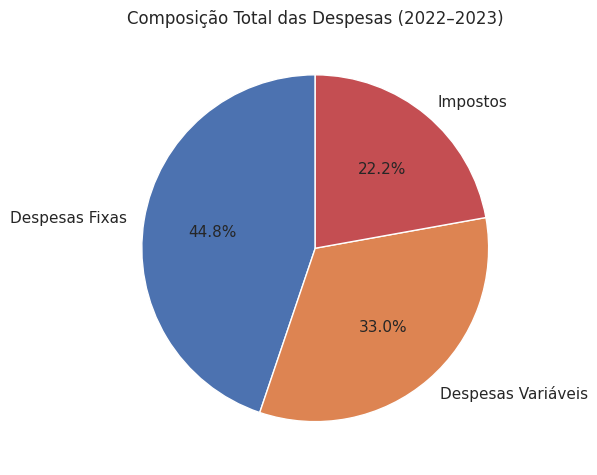

In [16]:
comp = df[['despesas_fixas','despesas_variaveis','impostos']].sum()

fig, ax = plt.subplots(figsize=(6,6))
ax.pie(comp, labels=['Despesas Fixas','Despesas Variáveis','Impostos'],
       autopct='%1.1f%%', startangle=90,
       colors=['#4C72B0','#DD8452','#C44E52'])
ax.set_title('Composição Total das Despesas (2022–2023)')
plt.tight_layout()
plt.show()

#7. Crescimento Anual por Setor

In [17]:
cresc = df.groupby(['setor','ano'])[['faturamento','lucro_liquido']].sum().reset_index()
cresc_pivot = cresc.pivot(index='setor', columns='ano', values='faturamento')
cresc_pivot['crescimento_%'] = ((cresc_pivot[2023] - cresc_pivot[2022]) / cresc_pivot[2022] * 100).round(2)

print('Crescimento do Faturamento 2022 → 2023:')
print(cresc_pivot[['crescimento_%']].to_string())

Crescimento do Faturamento 2022 → 2023:
ano         crescimento_%
setor                    
Comercial           18.06
Operações           18.89
Tecnologia          13.94


#ANÁLISE FINAL



In [19]:
import warnings
warnings.filterwarnings('ignore')

fat_2022 = df[df['ano']==2022]['faturamento'].sum()
fat_2023 = df[df['ano']==2023]['faturamento'].sum()
cresc_fat = ((fat_2023 - fat_2022) / fat_2022 * 100)

luc_2022 = df[df['ano']==2022]['lucro_liquido'].sum()
luc_2023 = df[df['ano']==2023]['lucro_liquido'].sum()
cresc_luc = ((luc_2023 - luc_2022) / luc_2022 * 100)

margem_2022 = (luc_2022 / fat_2022 * 100)
margem_2023 = (luc_2023 / fat_2023 * 100)

melhor_setor = df.groupby('setor')['lucro_liquido'].sum().idxmax()
pior_setor   = df.groupby('setor')['lucro_liquido'].sum().idxmin()

melhor_mes = df.groupby('mes')['faturamento'].sum().idxmax()


analise = f"""
╔══════════════════════════════════════════════════════════════╗
              ANÁLISE FINANCEIRA — 2022 vs 2023
╚══════════════════════════════════════════════════════════════╝

📈 FATURAMENTO
   • 2022: R$ {fat_2022:,.0f}
   • 2023: R$ {fat_2023:,.0f}
   • Crescimento: {cresc_fat:.1f}%

💰 LUCRO LÍQUIDO
   • 2022: R$ {luc_2022:,.0f}
   • 2023: R$ {luc_2023:,.0f}
   • Crescimento: {cresc_luc:.1f}%

📊 MARGEM DE LUCRO
   • 2022: {margem_2022:.1f}%
   • 2023: {margem_2023:.1f}%

🏆 DESEMPENHO POR SETOR
   • Melhor setor (lucro acumulado): {melhor_setor}
   • Setor com menor lucro:          {pior_setor}

📅 SAZONALIDADE
   • Mês com maior faturamento médio: {melhor_mes}

📝 CONCLUSÃO
   A empresa apresentou crescimento consistente de {cresc_fat:.1f}% no
   faturamento entre 2022 e 2023. O setor {melhor_setor} liderou em
   geração de lucro, enquanto {pior_setor} teve o menor desempenho.
   A margem de lucro {'melhorou' if margem_2023 > margem_2022 else 'recuou'} de
   {margem_2022:.1f}% para {margem_2023:.1f}%, indicando
   {'maior eficiência operacional' if margem_2023 > margem_2022 else 'aumento proporcional das despesas'}.
   O padrão sazonal mostra pico de faturamento em {melhor_mes},
   sugerindo concentração de receita no fim do ano.
"""

print(analise)


╔══════════════════════════════════════════════════════════════╗
              ANÁLISE FINANCEIRA — 2022 vs 2023
╚══════════════════════════════════════════════════════════════╝

📈 FATURAMENTO
   • 2022: R$ 4,413,000
   • 2023: R$ 5,143,000
   • Crescimento: 16.5%

💰 LUCRO LÍQUIDO
   • 2022: R$ 2,390,300
   • 2023: R$ 2,854,900
   • Crescimento: 19.4%

📊 MARGEM DE LUCRO
   • 2022: 54.2%
   • 2023: 55.5%

🏆 DESEMPENHO POR SETOR
   • Melhor setor (lucro acumulado): Tecnologia
   • Setor com menor lucro:          Operações

📅 SAZONALIDADE
   • Mês com maior faturamento médio: Dezembro

📝 CONCLUSÃO
   A empresa apresentou crescimento consistente de 16.5% no
   faturamento entre 2022 e 2023. O setor Tecnologia liderou em
   geração de lucro, enquanto Operações teve o menor desempenho.
   A margem de lucro melhorou de
   54.2% para 55.5%, indicando
   maior eficiência operacional.
   O padrão sazonal mostra pico de faturamento em Dezembro,
   sugerindo concentração de receita no fim do ano.